# 02 - Train CartPole with Q-learning
A compact CPU-friendly implementation of tabular Q-learning.

In [1]:
import gymnasium as gym
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
BINS = (8, 8, 12, 12)
STATE_LIMITS = np.array([2.4, 3.0, 0.2095, 3.5], dtype=np.float32)
N_ACTIONS = 2
print('State table size:', np.prod(BINS) * N_ACTIONS)

State table size: 18432


In [3]:
def discretize(observation):
    clipped = np.clip(observation, -STATE_LIMITS, STATE_LIMITS)
    scaled = (clipped + STATE_LIMITS) / (2 * STATE_LIMITS)
    indices = (scaled * np.array(BINS)).astype(int)
    return tuple(np.clip(indices, 0, np.array(BINS)-1))

In [4]:
q_table = np.zeros(BINS + (N_ACTIONS,), dtype=np.float32)
print(q_table.shape, q_table.nbytes / 1024, 'KB')

(8, 8, 12, 12, 2) 72.0 KB


In [5]:
def choose_action(state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(q_table[state]))

In [6]:
env = gym.make('CartPole-v1')
rng = np.random.default_rng(42)
learning_rate = 0.10
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
episodes = 500

In [7]:
episode_rewards = []
print('Training episodes:', episodes)

Training episodes: 500


In [8]:
for episode in range(episodes):
    observation, _ = env.reset(seed=episode)
    state = discretize(observation)
    total_reward = 0.0
    for _ in range(500):
        action = choose_action(state, epsilon, rng)
        next_observation, reward, terminated, truncated, _ = env.step(action)
        next_state = discretize(next_observation)
        best_next = np.max(q_table[next_state])
        target = reward if (terminated or truncated) else reward + gamma * best_next
        q_table[state + (action,)] += learning_rate * (target - q_table[state + (action,)])
        state = next_state
        total_reward += reward
        if terminated or truncated:
            break
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    if (episode + 1) % 50 == 0:
        print(f'Episode {episode+1}: reward={total_reward:.0f}, epsilon={epsilon:.3f}')
env.close()

Episode 50: reward=17, epsilon=0.778
Episode 100: reward=19, epsilon=0.606
Episode 150: reward=46, epsilon=0.471
Episode 200: reward=18, epsilon=0.367
Episode 250: reward=19, epsilon=0.286
Episode 300: reward=15, epsilon=0.222
Episode 350: reward=20, epsilon=0.173
Episode 400: reward=20, epsilon=0.135
Episode 450: reward=38, epsilon=0.105
Episode 500: reward=20, epsilon=0.082


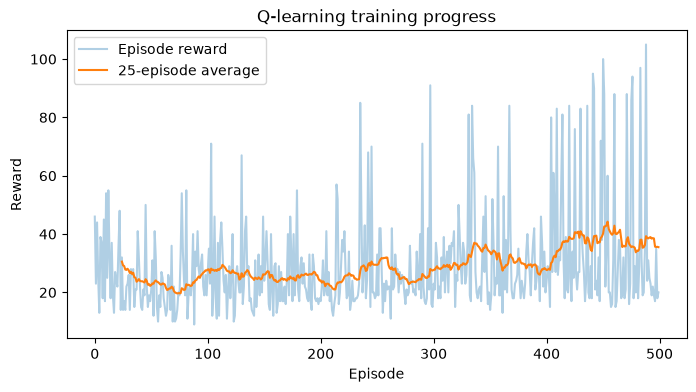

In [9]:
window = 25
moving = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.figure(figsize=(8,4))
plt.plot(episode_rewards, alpha=0.35, label='Episode reward')
plt.plot(range(window-1, len(episode_rewards)), moving, label='25-episode average')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Q-learning training progress')
plt.legend()
plt.show()

In [10]:
model_path = Path('../models/q_table.npy')
model_path.parent.mkdir(parents=True, exist_ok=True)
np.save(model_path, q_table)
print('Saved:', model_path.resolve())

Saved: C:\Users\user\Desktop\Reinforcement-Learning-CartPole\models\q_table.npy


In [11]:
loaded = np.load(model_path)
print('Reloaded shape:', loaded.shape)
print('Model size:', loaded.nbytes / 1024, 'KB')

Reloaded shape: (8, 8, 12, 12, 2)
Model size: 72.0 KB


## Interview takeaway
This implementation demonstrates state discretization, epsilon-greedy exploration, temporal-difference learning, reward tracking and model persistence without requiring a GPU.